# TCR spatial

Here TCR spatial distribution and shared clones across tissues are explored.

In [1]:
setwd("/scratch_isilon/groups/singlecell/shared/projects/covid-pascual-reguant")

## Libraries

In [2]:
library(glue)
library(here)
library(tidyverse)
library(tidytext)
library(patchwork)
library(Biostrings)
library(SpatialExperiment)
library(HDF5Array)
library(ggalluvial)
library(ggspavis)
library(ggVennDiagram)
library(ggforce)
library(viridis)
library(patchwork)
library(ComplexHeatmap)
library(circlize)
library(viridis)
library(svglite)

here() starts at /scratch_isilon/groups/singlecell/shared/projects/covid-pascual-reguant

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: BiocGenerics

Loading required package: generics


Attaching package: ‘generics’


The following object is masked from ‘package:lubridate’:

    as.difftime


The following object is masked from ‘package:dplyr’:

    explain


The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    se

## Parameters

In [3]:
source(here::here("misc/paths.R"))

Rows: 20 Columns: 17
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (17): donor_id, study_id, disease_group, sex, age, sars-cov-2_antemortem...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


## Load data

In [4]:
tcr_df <- "{tcr_sp}/tcrs-meb.tsv" %>%
    glue() %>%
    here() %>%
    readr::read_tsv(file = .) %>% data.frame()

tcr_df <- tcr_df %>%
    dplyr::rename(cond_tissue = study_id_tissue) %>%
    mutate(tissue = case_when(str_detect(tolower(cond_tissue), "lung") ~ "lung",
                              str_detect(tolower(cond_tissue), "lymph-node") ~ "lymph-node",
                              TRUE ~ "unknown"),
           condition = case_when(str_detect(tolower(cond_tissue), "control") ~ "control",
                                 str_detect(tolower(cond_tissue), "acute") ~ "acute",
                                 str_detect(tolower(cond_tissue), "chronic") ~ "chronic",
                                 str_detect(tolower(cond_tissue), "prolonged") ~ "prolonged",
                                 TRUE ~ "unknown"),
           chain = case_when(str_detect(allVHitsWithScore, "TRAV") ~ "TRA",
                             str_detect(allVHitsWithScore, "TRBV") ~ "TRB",
                             TRUE ~ "unknown"),
           cdr3_length = nchar(as.character(aaSeqCDR3)))  %>%
    filter(cond_tissue != "chronic_case_4-lung")

process_spe <- function(spe) {
    rownames(spatialCoords(spe)) <- paste(colData(spe)$cond_tissue, rownames(spatialCoords(spe)), sep = "_")
    colnames(spe) <- paste(colData(spe)$cond_tissue, colnames(spe), sep = "_")
    rowData(spe)$ensembl <- rownames(spe)
    rownames(spe) <- rowData(spe)$gene_name
    spe
}

spe_lung <- loadHDF5SummarizedExperiment(dir = "~/SP-COVID/visium/0-processing/out/3-annot_lung_spe") |> process_spe()
spe_ln <- loadHDF5SummarizedExperiment(dir = "~/SP-COVID/visium/0-processing/out/3-annot_ln_spe") |> process_spe()

load_deconv_mat <- function(tissue) {
    mat_filtered <- readRDS(here(glue("~/SP-COVID/visium/1-deconvolution/out/mat_filtered_{tissue}.rds")))
    return(mat_filtered)
}

mat_filtered_lung <- load_deconv_mat("lung")
mat_filtered_ln <- load_deconv_mat("ln")

Rows: 1345 Columns: 42
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (30): tagValueCELL, targetSequences, targetQualities, allVHitsWithScore,...
dbl (10): cloneId, readCount, uniqueMoleculeCount, minQualFR1, minQualCDR1, ...
lgl  (2): allCHitsWithScore, allCAlignments

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [5]:
mat_filtered_lung %>%
    as.data.frame() %>%
    rownames_to_column("spot_id") %>%
    mutate(sample_id = sub("-lung_.*", "", spot_id)) %>%
    group_by(sample_id) %>%
    summarise(prop_tcells = mean(`T cells`),
              pct_tcells = prop_tcells * 100,
              n_spots = n(),
              .groups = "drop") %>%
    mutate(disease_group = sub("_case_.*", "", sample_id)) %>%
    group_by(disease_group) %>%
    mutate(prop_tcells_group  = mean(prop_tcells),
           pct_tcells_group   = prop_tcells_group * 100) %>%
    ungroup() %>%
    arrange(factor(disease_group, levels = c("control", "acute", "chronic", "prolonged")),
            desc(prop_tcells)) %>%
    select(sample_id, disease_group, n_spots, everything()) %>%
    { 
      df <- .
      total_pct <- mean(df$prop_tcells) * 100
      cat(sprintf("Total %% across all samples: %.2f%%\n\n", total_pct))
      df
    }

Total % across all samples: 0.69%



sample_id,disease_group,n_spots,prop_tcells,pct_tcells,prop_tcells_group,pct_tcells_group
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
control_case_1,control,2825,0.0070622620,0.70622620,0.004615114,0.4615114
control_case_3,control,2571,0.0037695863,0.37695863,0.004615114,0.4615114
control_case_2,control,2075,0.0030134922,0.30134922,0.004615114,0.4615114
acute_case_2,acute,3177,0.0233173508,2.33173508,0.011009362,1.1009362
acute_case_1,acute,1877,0.0094050609,0.94050609,0.011009362,1.1009362
acute_case_3,acute,1852,0.0003056738,0.03056738,0.011009362,1.1009362
chronic_case_4,chronic,3813,0.0093529409,0.93529409,0.004984291,0.4984291
chronic_case_2,chronic,2886,0.0037031477,0.37031477,0.004984291,0.4984291
chronic_case_1,chronic,2890,0.0018967841,0.18967841,0.004984291,0.4984291


## Shared clones

Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.


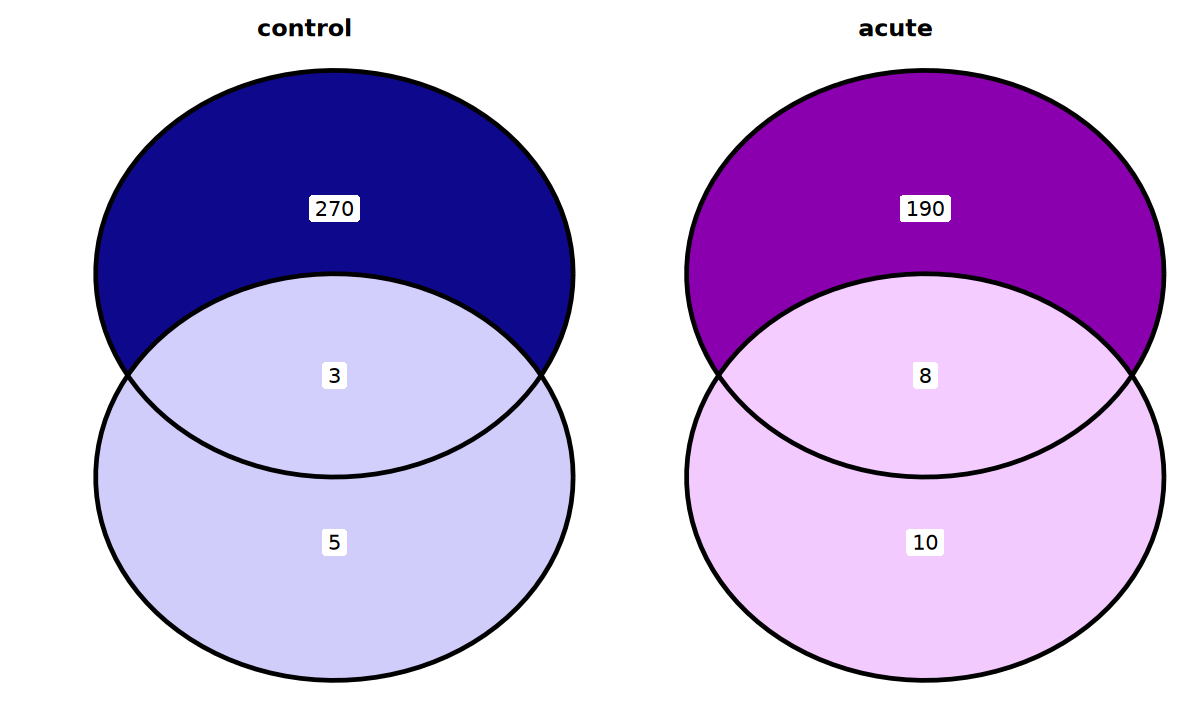

In [6]:
options(repr.plot.width = 10, repr.plot.height = 6, warn = -1)

condition_order <- c("control", "acute")
condition_colors <- c("control" = "#0E088D", "acute" = "#8A00AE")
low_colors <- c("control" = "#D2CFFC", "acute" = "#F4CCFF") 

clone_sets <- tcr_df %>%
  filter(!is.na(aaSeqCDR3),
         condition %in% condition_order) %>%
  select(condition, tissue, cond_tissue, aaSeqCDR3) %>%
  distinct() %>%
  mutate(condition = factor(condition, levels = condition_order))

venn_data <- clone_sets %>%
  group_by(condition) %>%
  group_map(~ list(condition = as.character(unique(.y$condition)),
                   sets = split(.x$aaSeqCDR3, .x$cond_tissue)))

plots <- lapply(venn_data, function(x) {
  sets <- x$sets
  names(sets) <- rep("", length(sets))   

  ggVennDiagram(sets, label_alpha = 1, label = "count",
                set_label_size = 0) +
    scale_fill_gradient(low  = low_colors[x$condition],
                        high = condition_colors[x$condition]) +
    labs(title = x$condition) +
    coord_cartesian(clip = "off") +
    theme(text = element_text(size = 16),
          legend.position = "none",
          plot.title  = element_text(hjust = 0.5, face = "bold", size = 14))
})

wrap_plots(plots, nrow = 1)
ggsave("~/SP-COVID/analysis/TCR/out/plots/venn_shared_CDR3.svg",
       width = 10, height = 6, device = svglite)

In [7]:
shared <- clone_sets %>%
  group_by(condition, aaSeqCDR3) %>%
  summarise(tissues = list(unique(tissue)), .groups = "drop") %>%
  filter(sapply(tissues, function(t) "lymph-node" %in% t),
                sapply(tissues, function(t) "lung" %in% t))

total_ln <- clone_sets %>%
  filter(tissue == "lymph-node") %>%
  group_by(condition) %>%
  summarise(total_LN_clonotypes = n_distinct(aaSeqCDR3), .groups = "drop")

shared %>%
  group_by(condition) %>%
  summarise(shared_clonotypes = n_distinct(aaSeqCDR3), .groups = "drop") %>%
  left_join(total_ln, by = "condition") %>%
  mutate(pct_LN_in_lung = round(shared_clonotypes / total_LN_clonotypes * 100, 2)) %>%
  print()

# A tibble: 2 × 4
  condition shared_clonotypes total_LN_clonotypes pct_LN_in_lung
  <fct>                 <int>               <int>          <dbl>
1 control                   3                 273           1.1 
2 acute                     8                 198           4.04


## Clonal dynamics

In the previous notebook, we saw a total of 11 clones defined by their CD3 AA sequence that were shared across tissues from the same studies across `control case 2` and `acute case 2`. We could also see how 2 of these clones were expanded in lungs from the acute case, specifically **CASSSGGGGSPLHF**and **CSVEGQSYEQYF**. Now we can visualize this clones in space:

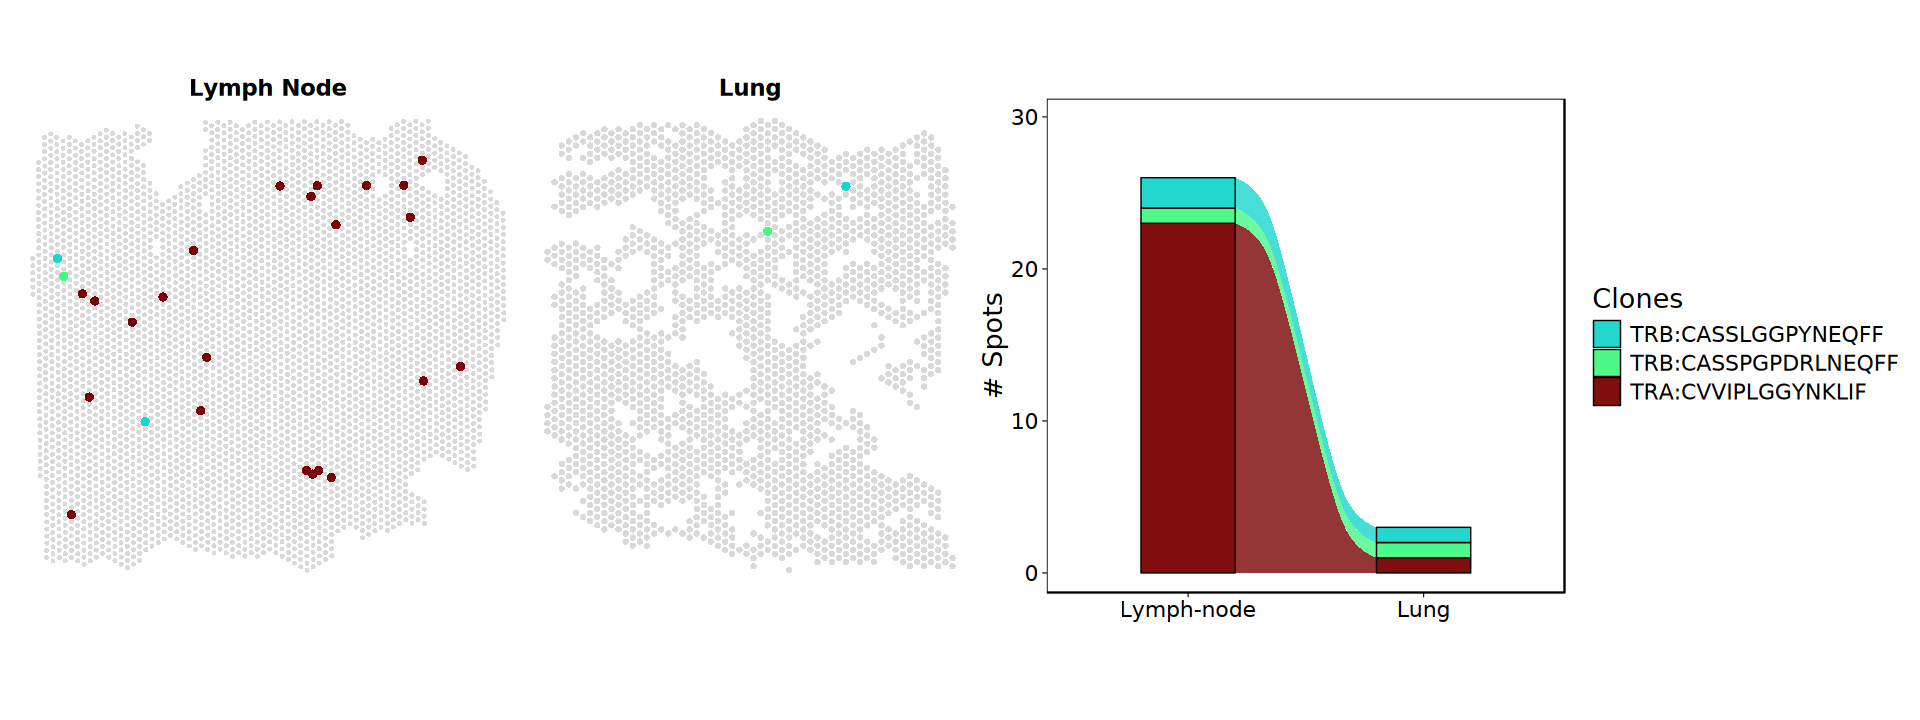

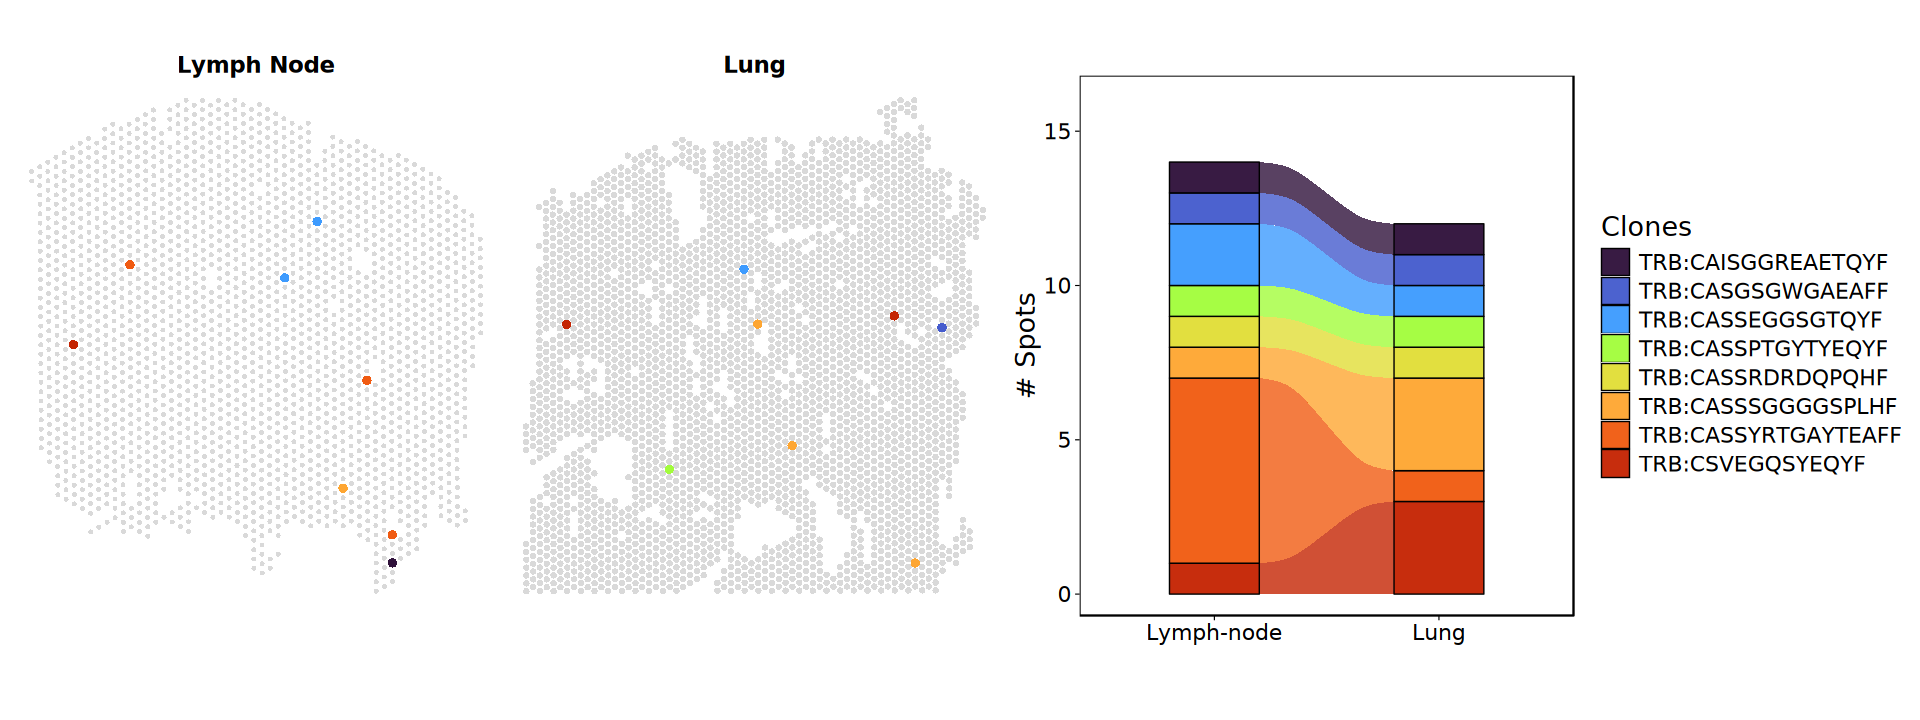

In [8]:
get_shared_clones <- function(tcr_df, cond, study_id) {
  prefix <- paste(cond, study_id, sep = "_")
  tcr_df %>%
    filter(condition == cond, cond_tissue %in% c(paste0(prefix, "-lymph-node"), paste0(prefix, "-lung"))) %>%
    group_by(aaSeqCDR3) %>%
    filter(n_distinct(tissue) > 1) %>%
    summarise(chain = dplyr::first(chain), .groups = "drop") %>%
    mutate(clone_label = paste(chain, aaSeqCDR3, sep = ":"))
}

plot_clones <- function(spe, study_id_filter, title, shared_df, tcr_df, spot_size = 0.8, highlight_size = 2) {
  spe_sub <- spe[, spe$study_id == study_id_filter]
  spe_bcs <- colnames(spe_sub)
  bc_cdr3 <- tcr_df %>%
    filter(aaSeqCDR3 %in% shared_df$aaSeqCDR3, bc %in% spe_bcs) %>%
    distinct(bc, aaSeqCDR3)
  coords <- as.data.frame(spatialCoords(spe_sub)) %>%
    mutate(clone    = bc_cdr3$aaSeqCDR3[match(spe_bcs, bc_cdr3$bc)] %>% replace_na("none"),
           dot_size = ifelse(clone == "none", spot_size, highlight_size)) %>%
    arrange(clone == "none")
  x_col <- names(coords)[1]
  y_col <- names(coords)[2]
  ggplot(coords, aes(x = .data[[x_col]], y = .data[[y_col]], color = clone, size = dot_size)) +
    geom_point(shape = 16) +
    scale_size_identity() +
    scale_color_manual(values = c(setNames(shared_df$color, shared_df$aaSeqCDR3), none = "grey85"),
                       breaks = shared_df$aaSeqCDR3,
                       labels = setNames(shared_df$clone_label, shared_df$aaSeqCDR3)) +
    scale_y_reverse() + coord_fixed() +
    labs(title = title, x = NULL, y = NULL, color = "CDR3") +
    theme_void() +
    theme(plot.title = element_text(hjust = 0.5, face = "bold"), 
          legend.position = "none")
}

plot_alluvial <- function(tcr_df, cond, study_id, clone_colors) {
  prefix <- paste(cond, study_id, sep = "_")
  plot_df <- tcr_df %>%
    filter(condition == cond, grepl(study_id, cond_tissue)) %>%
    group_by(aaSeqCDR3) %>%
    filter(n_distinct(tissue) > 1) %>%
    group_by(cond_tissue, aaSeqCDR3) %>%
    summarise(value = n(), .groups = "drop") %>%
    left_join(clone_colors, by = "aaSeqCDR3") %>%
    mutate(cond_tissue = factor(cond_tissue,
      levels = paste(prefix, c("lymph-node", "lung"), sep = "-"),
      labels = c("Lymph-node", "Lung")))
  ggplot(plot_df,
         aes(x = cond_tissue, y = value,
             stratum = aaSeqCDR3,
             alluvium = aaSeqCDR3,
             fill = aaSeqCDR3)) +
    geom_alluvium(alpha = 0.8, width = 0.4) +
    geom_stratum(alpha = 0.8, color = "black", linewidth = 0.3, width = 0.4) +
    scale_fill_manual(values = setNames(clone_colors$color, clone_colors$aaSeqCDR3),
                      labels = setNames(clone_colors$clone_label, clone_colors$aaSeqCDR3),
                      name = "Clones") +
    labs(x = "", y = "# Spots") +
    scale_y_continuous(breaks = scales::pretty_breaks(n = 4),
                       expand = expansion(mult = c(0.05, 0.2))) +
    theme_linedraw() +
    theme(text = element_text(size = 16),
          axis.text.x = element_text(hjust = 0.5),
          plot.title = element_text(hjust = 0.5, face = "bold"),
          panel.grid = element_blank(),
          legend.position = "right")
}

options(repr.plot.width = 16, repr.plot.height = 6, warn = -1)
stages <- c("control", "acute")
shared_list <- setNames(lapply(stages, function(st) get_shared_clones(tcr_df, st, "case_2")), stages)
clone_colors <- bind_rows(shared_list) %>%
  distinct(aaSeqCDR3, chain, clone_label) %>%
  arrange(aaSeqCDR3) %>%
  mutate(color = viridis(n(), option = "turbo"))
shared_list <- lapply(shared_list, function(df) left_join(df, clone_colors %>% select(aaSeqCDR3, color), by = "aaSeqCDR3"))

for (st in stages) {
    p_spatial <- plot_clones(spe_ln, paste0(st, "_case_2"), "Lymph Node", 
                             shared_list[[st]], tcr_df, 0.8) |
    plot_clones(spe_lung, paste0(st, "_case_2"), "Lung",       
                shared_list[[st]], tcr_df, 1.2)
    p_alluv <- plot_alluvial(tcr_df, st, "case_2", clone_colors)
    
    p <- p_spatial + p_alluv
    print(p)
    ggsave(paste0("~/SP-COVID/analysis/TCR/out/plots/shared_clones_", st, ".svg"), plot = p, device = svglite, width = 16, height = 6)
}

In [9]:
tcr_df %>%
    filter(condition == "acute") %>%
    group_by(aaSeqCDR3) %>%
    filter(n_distinct(tissue) > 1) %>%
    group_by(cond_tissue, aaSeqCDR3) %>%
    summarise(value = n(), .groups = "drop") 

cond_tissue,aaSeqCDR3,value
<chr>,<chr>,<int>
acute_case_2-lung,CAISGGREAETQYF,1
acute_case_2-lung,CASGSGWGAEAFF,1
acute_case_2-lung,CASSEGGSGTQYF,1
acute_case_2-lung,CASSPTGYTYEQYF,1
acute_case_2-lung,CASSRDRDQPQHF,1
acute_case_2-lung,CASSSGGGGSPLHF,3
acute_case_2-lung,CASSYRTGAYTEAFF,1
acute_case_2-lung,CSVEGQSYEQYF,3
acute_case_2-lymph-node,CAISGGREAETQYF,1


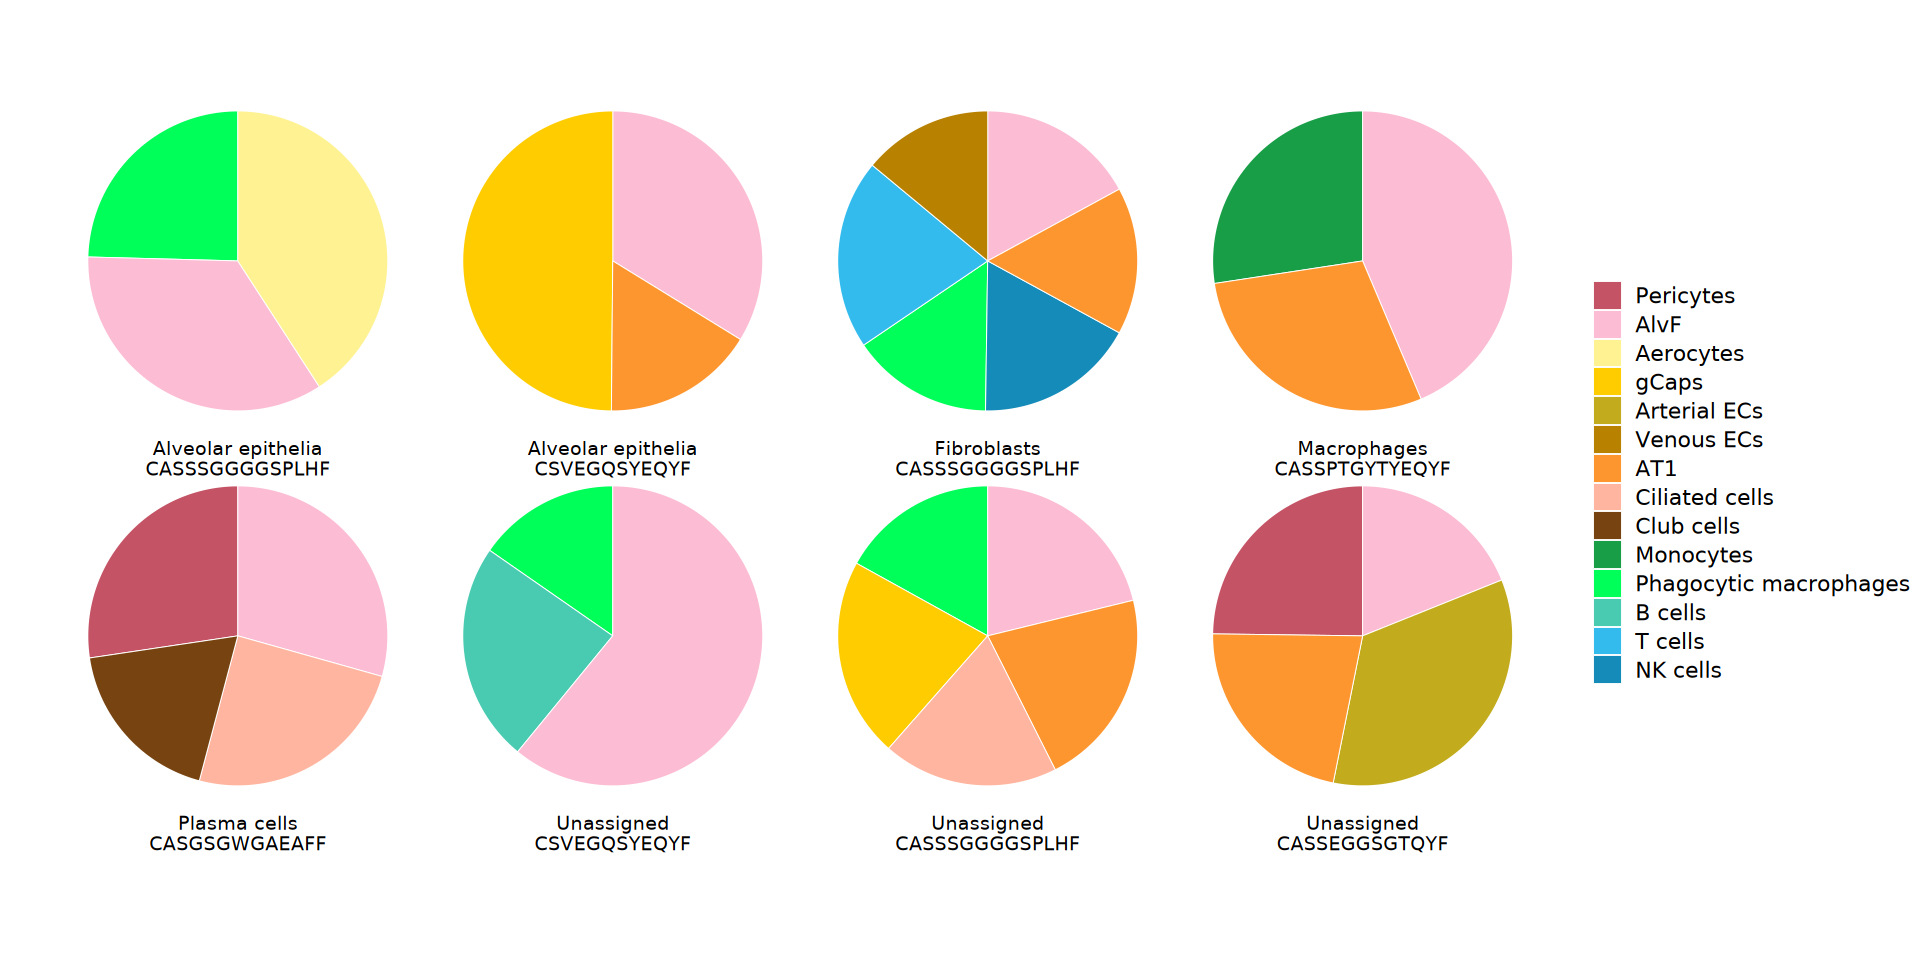

In [10]:
options(repr.plot.width = 16, repr.plot.height = 8, warn = -1)

shared_cdr3_acute <- clone_sets %>%
  filter(condition == "acute") %>%
  group_by(aaSeqCDR3) %>%
  summarise(tissues = list(unique(tissue)), .groups = "drop") %>%
  filter(
    sapply(tissues, function(t) "lymph-node" %in% t),
    sapply(tissues, function(t) "lung" %in% t)
  ) %>%
  pull(aaSeqCDR3)
           
shared_bcs_lung <- tcr_df %>%
  filter(condition == "acute",
         tissue == "lung",
         !is.na(aaSeqCDR3),
         aaSeqCDR3 %in% shared_cdr3_acute) %>% 
  select(bc, aaSeqCDR3) %>%
  distinct() %>%
  filter(bc %in% colnames(spe_lung))

bc_lookup <- shared_bcs_lung %>% select(spot_id = bc, aaSeqCDR3)
annotation_lookup <- data.frame(spot_id = colnames(spe_lung), annotation = colData(spe_lung)$annotation) %>% filter(spot_id %in% rownames(mat_filtered_lung))

n_spots <- 8
n_cols <- 4

relevant_spots <- shared_bcs_lung$bc
mat_sub <- mat_filtered_lung[rownames(mat_filtered_lung) %in% relevant_spots, ]

pie_df <- mat_sub %>%
  as.data.frame() %>%
  tibble::rownames_to_column("spot_id") %>%
  left_join(bc_lookup, by = "spot_id") %>%
  left_join(annotation_lookup, by = "spot_id") %>%
  pivot_longer(-c(spot_id, aaSeqCDR3, annotation),
               names_to = "cell_type", values_to = "proportion") %>%
  group_by(spot_id) %>%
  filter(any(proportion > 0)) %>%
  filter(proportion > 0) %>%
  ungroup()

spot_positions <- pie_df %>%
  distinct(spot_id, aaSeqCDR3, annotation) %>%
  arrange(annotation) %>%                       
  mutate(spot_label = paste0(annotation, "\n",substr(spot_id, nchar("acute_case_2-lung_") + 1,
                                                     nchar("acute_case_2-lung_") + 8), "..."),
         col = (row_number() - 1) %% n_cols,
         row = (row_number() - 1) %/% n_cols)

spot_positions <- pie_df %>%
  distinct(spot_id, aaSeqCDR3, annotation) %>%
  arrange(annotation) %>%
  mutate(spot_label = paste0(annotation, "\n", aaSeqCDR3),
         col = (row_number() - 1) %% n_cols,
         row = (row_number() - 1) %/% n_cols)

pie_df <- pie_df %>% left_join(spot_positions, by = c("spot_id", "aaSeqCDR3", "annotation"))
palette <- c("SMC" = "#FF3071", "Pericytes" = "#C45365",
             "AdvF" = "#E87FD8", "AlvF" = "#FCBCD3", 
             "Aerocytes" = "#FFF292", "gCaps" = "#FFCC00", "Arterial ECs" = "#C2AC1D", "Venous ECs" = "#B88100", "Lymphatic ECs" = "#FFE100",
             "AT1" = "#FE962F", "AT2" = "#FFC58B", "Basal cells" = "#FF7A54", "Ciliated cells" = "#FFB59F", "Club cells" = "#774411",
             "Monocytes" = "#179E46", "Inflammatory Macrophages" = "#92AD24", "Anti-inflammatory Macrophages" = "#C4E75D", "Phagocytic macrophages" = "#00FF59",
             "Mast cells" = "#53FFDD", "B cells" = "#48CBB1", "PCs" = "#268874", "T cells" = "#33BBEE", "NK cells" = "#148BB8")
present_celltypes <- intersect(names(palette), unique(pie_df$cell_type))
pie_df <- pie_df %>% mutate(cell_type = factor(cell_type, levels = present_celltypes))

p <- ggplot(pie_df) +
  geom_arc_bar(aes(x0 = col, y0 = -row, r0 = 0, r = 0.4, amount = proportion, fill = cell_type), stat = "pie", color = "white", linewidth = 0.2) +
  geom_text(data = spot_positions, aes(x = col, y = -row - 0.48, label = spot_label), size = 4, hjust = 0.5, vjust = 1, lineheight = 0.9) +
  scale_fill_manual(values = palette[present_celltypes],
                    name = "",
                    breaks = present_celltypes,   
                    drop = FALSE) +
  coord_fixed() +
  theme_void(base_size = 16) +
  theme(legend.position = "right",
        plot.margin = margin(10, 10, 30, 10)) 
print(p)

ggsave("~/SP-COVID/analysis/TCR/out/plots/shared_clones_pie_acute_lung.svg",
       plot = p, device = svglite, width = 16, height = 8)

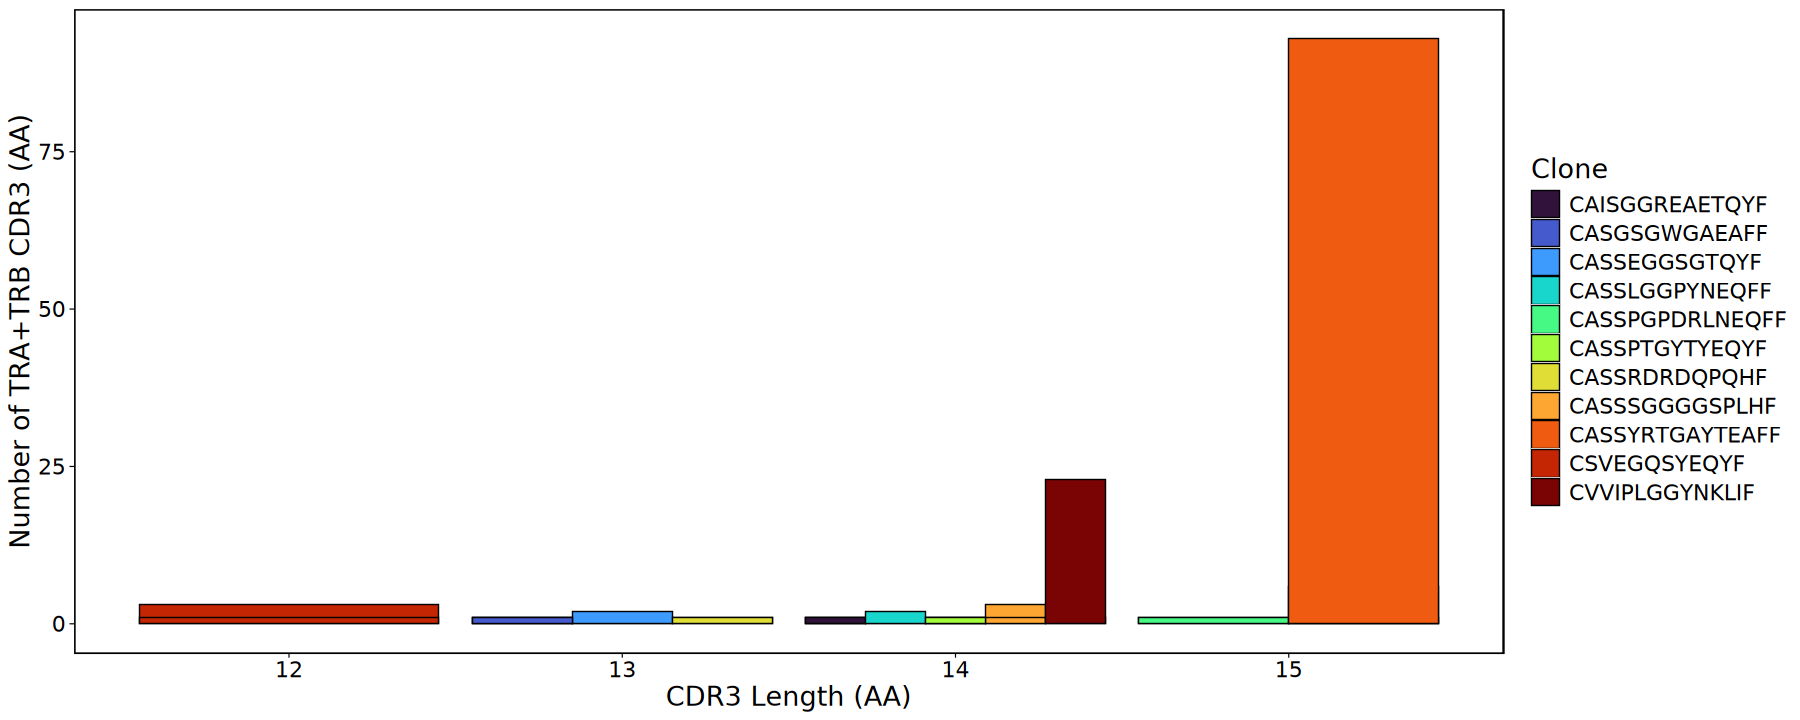

In [11]:
options(repr.plot.width = 15, repr.plot.height = 6, warn = -1)

p <- tcr_df %>%
    filter(aaSeqCDR3 %in% clone_colors$aaSeqCDR3,
           cond_tissue %in% c("control_case_2-lung", "control_case_2-lymph-node",
                              "acute_case_2-lung",   "acute_case_2-lymph-node")) %>%
    mutate(chain = case_when(str_detect(allVHitsWithScore, "TRAV") ~ "TRA",
                             str_detect(allVHitsWithScore, "TRBV") ~ "TRB",
                             TRUE ~ "unknown"),
           cdr3_length = nchar(as.character(aaSeqCDR3))) %>%
    filter(chain %in% c("TRA", "TRB")) %>%
    group_by(cond_tissue, cdr3_length, aaSeqCDR3) %>%
    summarise(count = n(), .groups = "drop") %>%
    ggplot(aes(x = cdr3_length, y = count, fill = aaSeqCDR3)) +
    geom_bar(stat = "identity", position = "dodge", color = "black", linewidth = 0.3) +
    scale_fill_manual(values = setNames(clone_colors$color, clone_colors$aaSeqCDR3), drop = FALSE) +
    labs(x = "CDR3 Length (AA)", y = "Number of TRA+TRB CDR3 (AA)", fill = "Clone") +
    theme_linedraw() +
    theme(text = element_text(size = 16),
          legend.position = "right", 
          panel.grid = element_blank())
print(p)
ggsave("~/SP-COVID/analysis/TCR/out/plots/shared_clonescd3lenght.svg", plot = p, device = svglite, width = 15, height = 6)

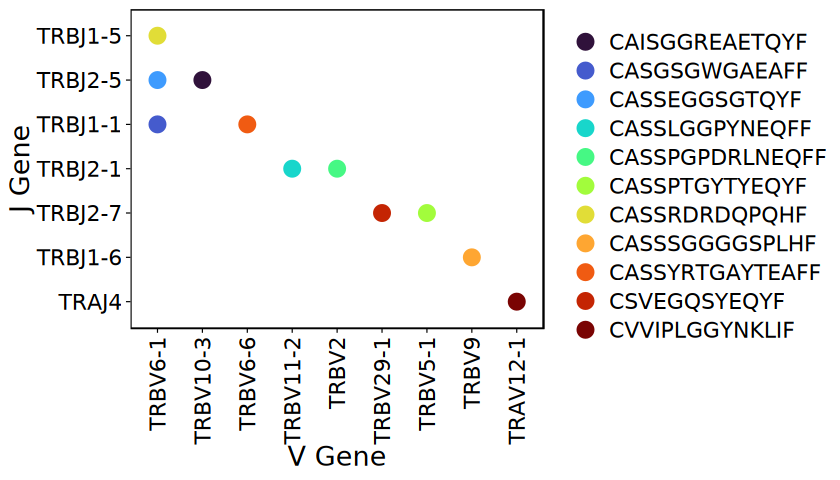

In [12]:
options(repr.plot.width = 7, repr.plot.height = 4, warn = -1)

v_order <- c("TRBV6-1", "TRBV10-3", "TRBV6-6", "TRBV11-2", "TRBV2", 
             "TRBV29-1", "TRBV5-1", "TRBV9", "TRAV12-1")
j_order <- c( "TRAJ4","TRBJ1-6", "TRBJ2-7", "TRBJ2-1",
             "TRBJ1-1", "TRBJ2-5", "TRBJ1-5")
clean_gene <- function(x) sub("\\*.*$", "", x)
p <- tcr_df %>%
    filter(aaSeqCDR3 %in% clone_colors$aaSeqCDR3) %>%
    mutate(v_gene = str_extract(as.character(allVHitsWithScore), "TR[AB]V[^\\(]*"),
           j_gene = str_extract(as.character(allJHitsWithScore), "TR[AB]J[^\\(]*")) %>%
    mutate(v_gene = clean_gene(v_gene),
           j_gene = clean_gene(j_gene))%>%
    filter(!is.na(v_gene), !is.na(j_gene)) %>%
    distinct(aaSeqCDR3, v_gene, j_gene) %>%
    left_join(clone_colors, by = "aaSeqCDR3") %>%
    mutate(v_gene = factor(v_gene, levels = v_order),
           j_gene = factor(j_gene, levels = j_order)) %>%
    ggplot(aes(x = v_gene, y = j_gene, color = aaSeqCDR3)) +
    geom_point(size = 4) +
    scale_color_manual(values = setNames(clone_colors$color, clone_colors$aaSeqCDR3), drop = FALSE) +
    labs(x = "V Gene", y = "J Gene", color = "") +
    theme_linedraw() +
    theme(text = element_text(size = 16),
          axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5),  
          panel.grid = element_blank())
print(p)
ggsave("~/SP-COVID/analysis/TCR/out/plots/v_j_gene_usage.svg", plot = p, device = svglite, width = 7, height = 4)

## Distribution of clones across spatial domains

In [13]:
options(repr.plot.width = 20, repr.plot.height = 6, warn = -1)

anno_lung <- as.data.frame(colData(spe_lung)) %>%
  rownames_to_column("bc") %>%
  select(bc, annotation) %>%
  mutate(annotation = as.character(annotation))

anno_ln <- as.data.frame(colData(spe_ln)) %>%
  rownames_to_column("bc") %>%
  select(bc, annotation) %>%
  mutate(annotation = as.character(annotation))

anno <- bind_rows(anno_lung, anno_ln)

tcr_anno <- tcr_df %>%
  filter(!is.na(aaSeqCDR3), !grepl("_", aaSeqCDR3)) %>%  
  left_join(anno, by = "bc") %>%
  filter(!is.na(annotation))

lung_annotations <- unique(tcr_anno$annotation[tcr_anno$tissue == "lung"])
ln_annotations   <- unique(tcr_anno$annotation[tcr_anno$tissue == "lymph-node"])
lung_colors <- setNames(RColorBrewer::brewer.pal(max(3, length(lung_annotations)), "Paired")[seq_along(lung_annotations)], lung_annotations)
ln_colors   <- setNames(RColorBrewer::brewer.pal(max(3, length(ln_annotations)),   "Paired")[seq_along(ln_annotations)],   ln_annotations)
condition_order_all <- c("control", "acute", "chronic", "prolonged")

plot_clones <- function(df, tissue_sel, colors) {
  df %>%
    filter(tissue == tissue_sel) %>%
    group_by(condition, annotation) %>%
    summarise(n_clones = n_distinct(aaSeqCDR3), .groups = "drop") %>%
    mutate(condition = factor(condition, levels = condition_order_all)) %>%
    ggplot(aes(x = annotation, y = n_clones, color = annotation, shape = condition)) +
    geom_jitter(width = 0.15, size = 6, alpha = 0.6) +
    scale_color_manual(values = colors) +
    scale_shape_manual(values = c("control" = 16, "acute" = 17,
                                  "chronic" = 15, "prolonged" = 18)) +
    labs(x = NULL, y = "Number of unique CDR3s") +
    theme_linedraw() +
    theme(text = element_text(size = 16),
          axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5),
          panel.grid = element_blank(),
          legend.position = "none")
}

plot_umi <- function(df, tissue_sel, colors) {
  df %>%
    filter(tissue == tissue_sel) %>%
    group_by(condition, annotation) %>%
    summarise(total_UMI = sum(uniqueMoleculeCount, na.rm = TRUE), .groups = "drop") %>%
    mutate(condition = factor(condition, levels = condition_order_all)) %>%
    ggplot(aes(x = annotation, y = total_UMI, color = annotation, shape = condition)) +
    geom_jitter(width = 0.15, size = 6, alpha = 0.6) +
    scale_color_manual(values = colors) +
    scale_shape_manual(values = c("control" = 16, "acute" = 17,
                                  "chronic" = 15, "prolonged" = 18)) +
    labs(x = NULL, y = "Sum of uniqueMoleculeCount") +
    theme_linedraw() +
    theme(text = element_text(size = 16),
          axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5),
          panel.grid = element_blank())
}

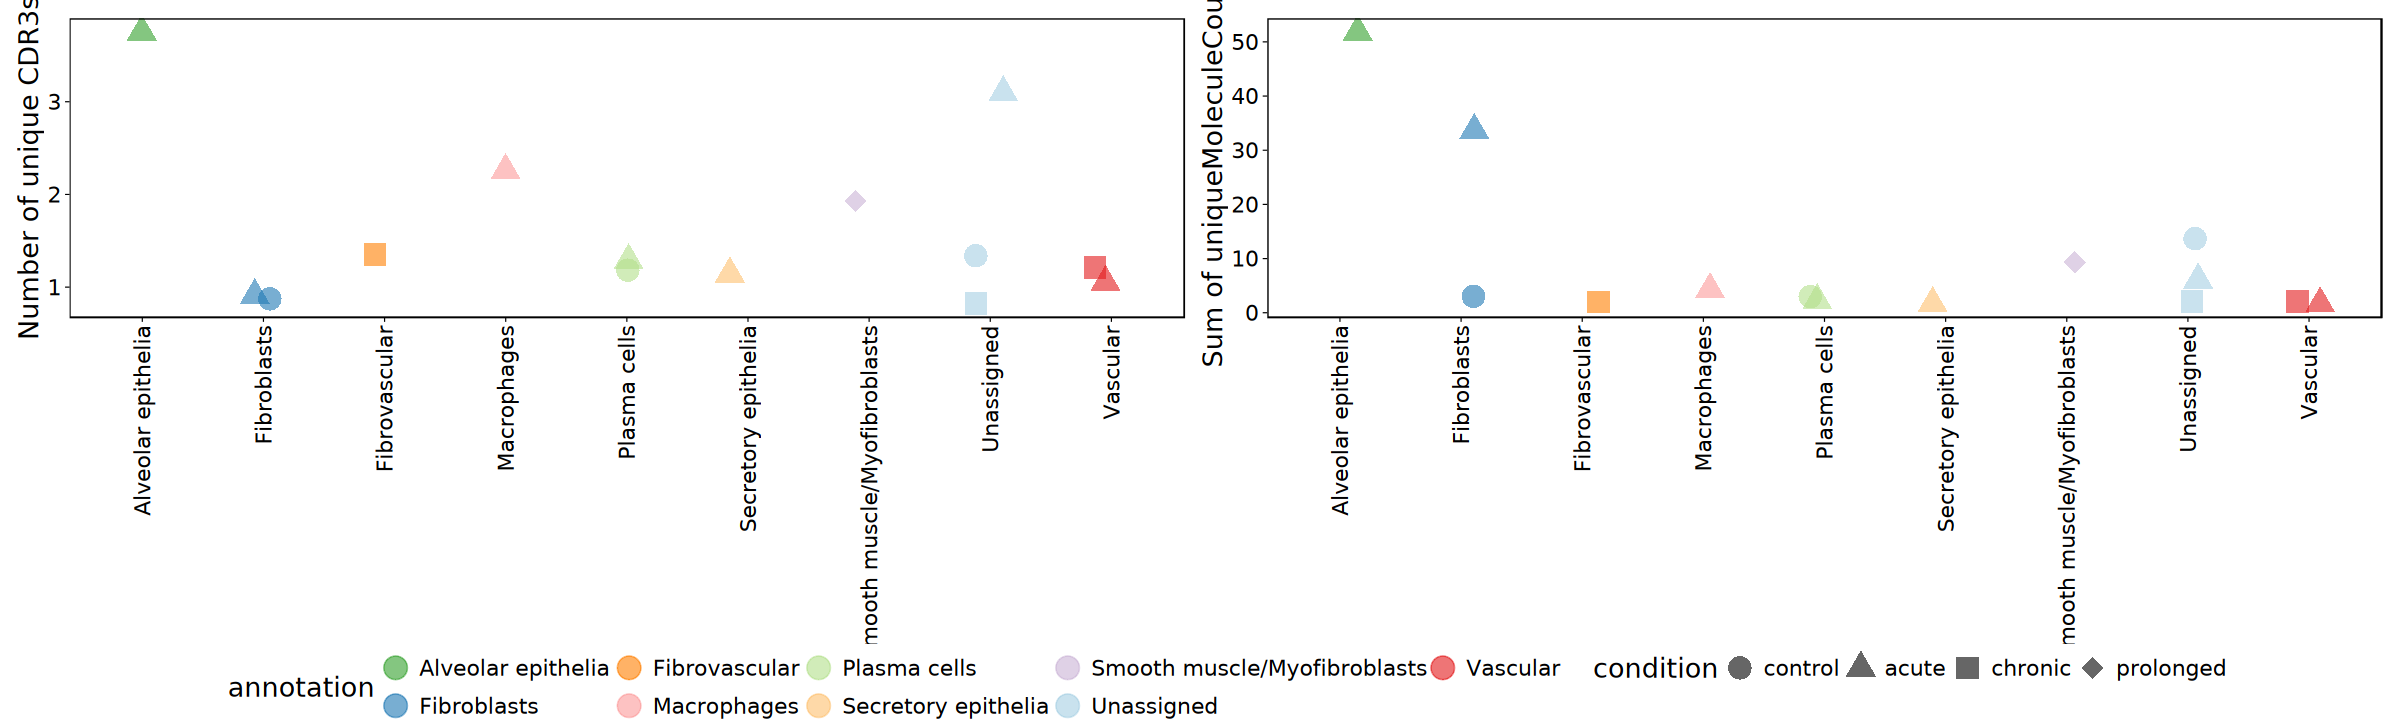

In [14]:
(plot_clones(tcr_anno, "lung", lung_colors) | plot_umi(tcr_anno, "lung", lung_colors)) /
  guide_area() +
  plot_layout(guides = "collect", heights = c(10, 1)) &
  theme(legend.position = "bottom")

ggsave("~/SP-COVID/analysis/TCR/out/plots/clones_per_domain_lung.svg",
       width = 20, height = 6, device = svglite)

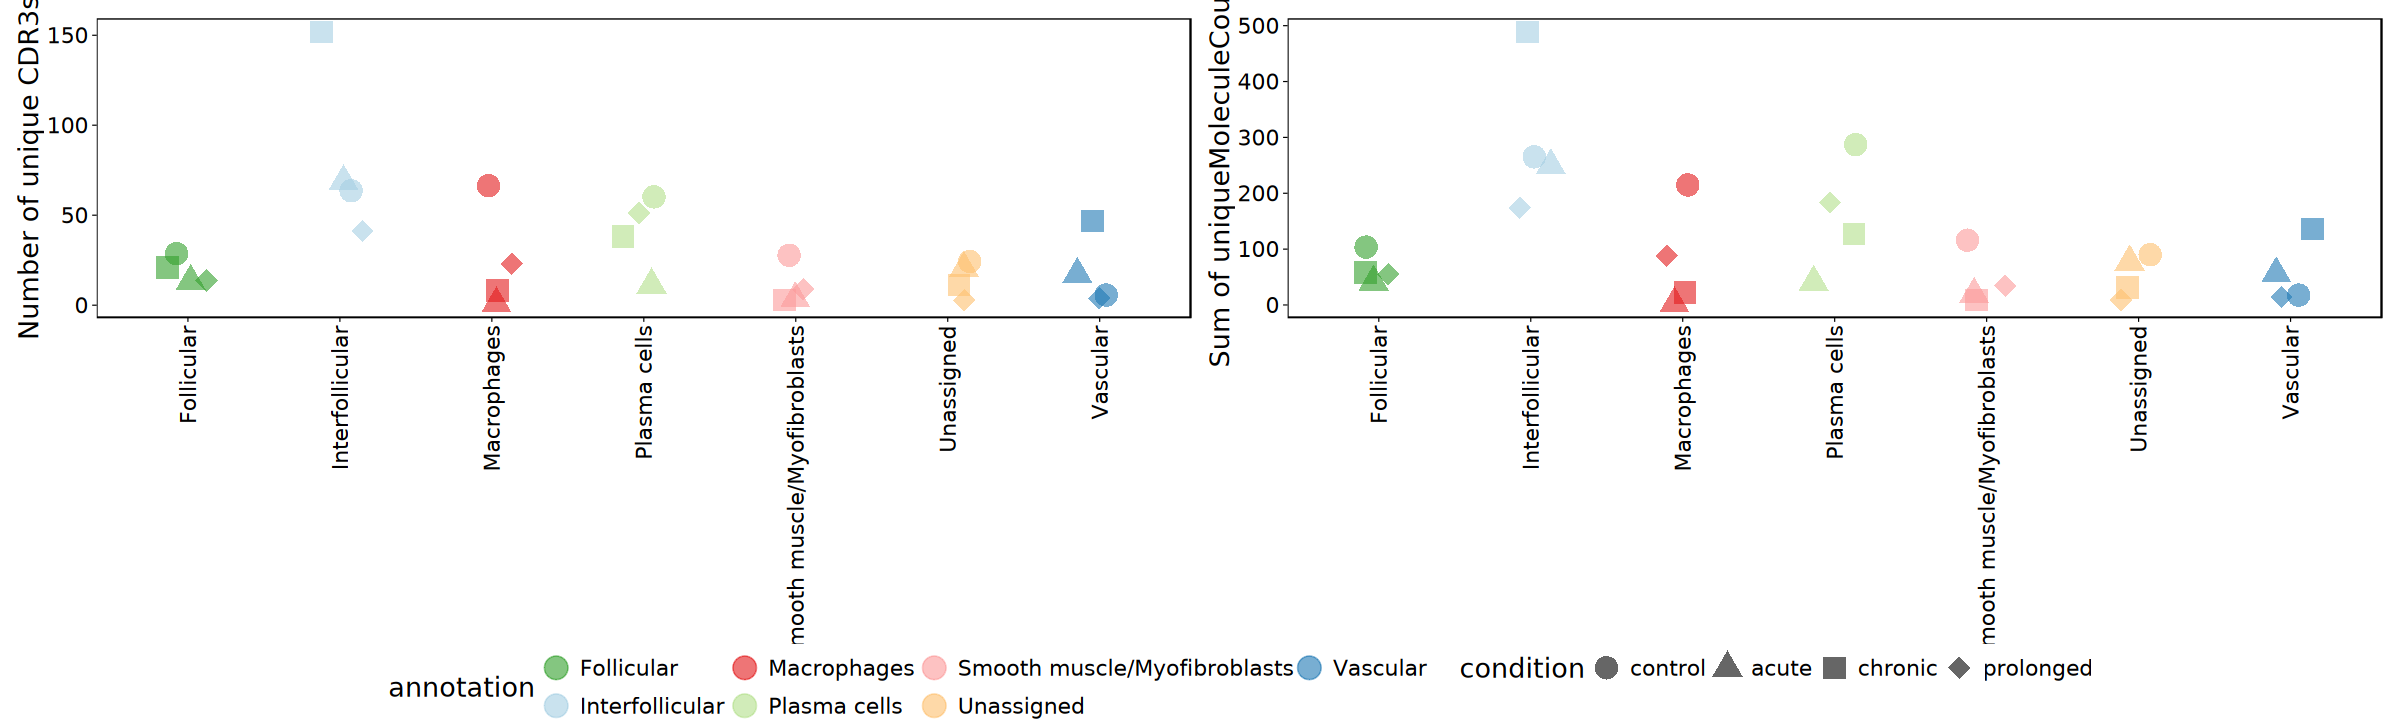

In [15]:
(plot_clones(tcr_anno, "lymph-node", ln_colors) | plot_umi(tcr_anno, "lymph-node", ln_colors)) /
  guide_area() +
  plot_layout(guides = "collect", heights = c(10, 1)) &
  theme(legend.position = "bottom")
ggsave("~/SP-COVID/analysis/TCR/out/plots/clones_per_domain_ln.svg",
       width = 20, height = 6, device = svglite)

# Session information

In [16]:
sessionInfo()

R version 4.5.2 (2025-10-31)
Platform: x86_64-conda-linux-gnu
Running under: CentOS Linux 7 (Core)

Matrix products: default
BLAS/LAPACK: /home/groups/singlecell/cvicente/miniconda3/envs/COVID/lib/libopenblasp-r0.3.30.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Europe/Madrid
tzcode source: system (glibc)

attached base packages:
[1] grid      stats4    stats     graphics  grDevices utils     datasets 
[8] methods   base     

other attached packages:
 [1] svglite_2.2.2               circlize_0.4.17            
 [3] ComplexHeatmap_2.26.1       viridis_0.6.5              
 [5] viridisLite_0.4.3           ggforce_0.5.0              
 [7]